<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Data Preprocessing" data-toc-modified-id="Data Preprocessing-1">Data Preprocessing</a></span></li><li><span><a href="#minute" data-toc-modified-id="minute-2">minute</a></span></li><li><span><a href="#featureextract" data-toc-modified-id="featureextract-3">featureextract</a></span></li><li><span><a href="#Naive Bayesmodel" data-toc-modified-id="Naive Bayesmodel-4">Naive Bayesmodel</a></span></li><li><span><a href="#" data-toc-modified-id="-5"></a></span></li></ul></div>

：

pip install gensim -i https://pypi.tuna.tsinghua.edu.cn/simple/

pip install nltk -i https://pypi.tuna.tsinghua.edu.cn/simple/

## Data Preprocessing

data

filecontainsdata
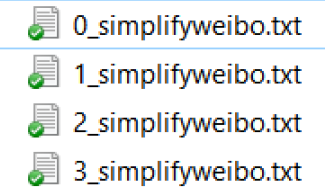
0：；1：；2：；3：

In [3]:
#datacsvfile，classification
import re
import pandas as pd
def proc_text(text):
    pos_words=[]
    pos_list=[]
    type_list = []
    for file in text:
        with open(file,encoding='UTF-8') as f:
            line = f.readline()
            while(line):
                line = line.strip('\n')
                line=re.sub('/[a-zA-Z]+', '',line).replace(" ","")
                pos_list.append(line)
                type_list.append(int(file[7]))
                line = f.readline()
    dataframe = pd.DataFrame({'text': pos_list, 'type': type_list})
    dataframe.to_csv("./data/data.csv", index=False, sep=',',encoding="utf_8_sig")
texts_list =['./data/0_simplifyweibo.txt','./data/1_simplifyweibo.txt','./data/2_simplifyweibo.txt','./data/3_simplifyweibo.txt']
proc_text(texts_list)

## minute

In [2]:
!pip install gensim -i https://pypi.tuna.tsinghua.edu.cn/simple/

!pip install nltk -i https://pypi.tuna.tsinghua.edu.cn/simple/

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/
     ---------------------------------------- 24.0/24.0 MB 2.3 MB/s eta 0:00:00
     ------------------------------------ 986.3/986.3 kB 992.0 kB/s eta 0:00:00
     ---------------------------------------- 56.8/56.8 kB 2.9 MB/s eta 0:00:00
     ---------------------------------------- 67.1/67.1 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for fst-pso: filename=fst_pso-1.8.1-py3-none-any.whl size=20448 sha256=8b8b51293e80ef380566a80efbae612468c4ba3d79cf5795560ed2db94a58748
  Stored in directory: c:\users\administrator\appdata\local\pip\cache\wheels\91\01\74\270f8856df7b02b845aee049119557bef96fc2b85c1213f976
  Created wheel for miniful: filename=miniful-0.0.6-py3-none-any.whl size=3522 sha256=90d0c3d3492ddf6600b4c159d39c0133accf511


[notice] A new release of pip available: 22.3.1 -> 23.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/
     ---------------------------------------- 1.5/1.5 MB 2.5 MB/s eta 0:00:00
     -------------------------------------- 96.6/96.6 kB 345.4 kB/s eta 0:00:00
     -------------------------------------- 267.8/267.8 kB 3.3 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 23.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import re
import jieba
from gensim.models import word2vec
# from nltk.classify import NaiveBayesClassifier
from sklearn import naive_bayes
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd


def chinese_word_cut(mytext):
    return " ".join(jieba.cut(mytext))

#
def get_custom_stopwords(stop_words_file):
    with open(stop_words_file) as f:
        stopwords = f.read()
    stopwords_list = stopwords.split('\n')
    custom_stopwords_list = [i for i in stopwords_list]
    return custom_stopwords_list

df = pd.read_csv('./data/data.csv')
X = df[['text']]
y = df.type

#Reviewminute
X['cut_text'] = X.text.apply(chinese_word_cut)
print(X['cut_text'][0:10])

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\ADMINI~1\AppData\Local\Temp\2\jieba.cache
Loading model cost 1.021 seconds.
Prefix dict has been built successfully.


0     ！   ！    ！       ，     ...
1                             ，   ！    ？
2      ，  D . I . Y .   1 .      ...
3     1  ，    1  ！      day  ...
4          【       1  different  】 ...
5      IPHONE4 。  ， hour ，    。   ...
6           ！     ，   1  ...
7       1       1  — — — —  … …...
8     ！      1        1 ...
9        can          ~ ~    HC ...
Name: cut_text, dtype: object


## Feature Extraction

In [2]:
#minuteTraining Set and Test Set，Training Set90%，Test Set10%
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1, random_state=0)
stop_words_file = './data/.txt'
#
stopwords = get_custom_stopwords(stop_words_file)
# Keywords（），。
max_df = 0.9
# CountKeywords（），。
min_df = 4 
#featureextract，using  CountVectorizer，。
#featureextractusing “”（bag of words）model。model，
# and 。feature。may  because Effectiveness。
vect = CountVectorizer(max_df = max_df,min_df = min_df,token_pattern=u'(?u)\\b[^\\d\\W]\\w+\\b',stop_words=stopwords)

## Naive Bayesmodel

In [3]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
#classificationmodel，using Naive Bayes
nb = MultinomialNB()
#utilizing (pipeline)vect  and  nb 
pipe = make_pipeline(vect, nb)
#viewmodel
#pipe.steps

In [4]:
#Training Set，kcross-validation，modelclassificationaccuracy。
#cvk，trainingsampleminutek，where （k-1）Training Set，evaluation，can classificationktraining，ktrainingresult。
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train.cut_text, y_train, cv=5, scoring='accuracy').mean()

C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\feature_extraction\text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens [''] not in stop_words.
  warnings.warn(
C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\feature_extraction\text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens [''] not in stop_words.
  warnings.warn(
C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\feature_extraction\text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens [''] not in stop_words.
  warnings.warn(
C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\feature_extraction\text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens [''] not in stop_words.
  warnings.warn(
C:\Users\Adm

0.6182672353812979

In [5]:
#using Training Set，model
pipe.fit(X_train.cut_text, y_train)
#Test Set，Sentimentclassificationprediction。
result=pipe.predict(X_test.cut_text)
#viewTest SetPrediction Results
print(result[0:50])

C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\feature_extraction\text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens [''] not in stop_words.
  warnings.warn(


[1 1 2 0 1 0 0 0 0 1 1 0 0 2 0 0 0 0 1 0 0 3 0 0 0 0 0 0 0 0 1 0 0 0 2 0 2
 0 0 0 0 0 2 2 1 0 0 0 0 0]


In [6]:
#Use scikit-learnmodel，Prediction Results and  for 
from sklearn import tree
from sklearn import metrics
TR = tree.DecisionTreeClassifier(criterion='entropy') 
corretcRate=metrics.accuracy_score(y_test,result)
print("test setPrediction Results：",corretcRate)
confusionMatrix=metrics.confusion_matrix(y_test, result)
print("Confusion Matrix：\n",confusionMatrix)

test setPrediction Results： 0.6287097137282858
Confusion Matrix：
 [[13505  1078  1048   385]
 [ 2098  1390   488   119]
 [ 2177   583  1590   126]
 [ 1279   301   214   272]]


In [7]:
# # 0：；1：；2：；3：
# result=pipe.predict([' ',' ']).tolist()
# result
#[0,0]

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn import tree
TR = tree.DecisionTreeClassifier(criterion='entropy') 

pipe = make_pipeline(vect, TR)
from sklearn.model_selection import cross_val_score

pipe.fit(X_train.cut_text, y_train)
result=pipe.predict(X_test.cut_text)

from sklearn import metrics
corretcRate=metrics.accuracy_score(y_test,result)
print("test setPrediction Results：",corretcRate)
confusionMatrix=metrics.confusion_matrix(y_test, result)
print("Confusion Matrix：\n",confusionMatrix)

In [ ]:
print(result[:10])
print(y_test[:10])
confusionMatrix=metrics.confusion_matrix([1,2,3], [1,2,3])
print("Confusion Matrix：\n",confusionMatrix)

## 

NLTK：http://www.nltk.org/

minute：https://baike.baidu.com/item/%E4%B8%AD%E6%96%87%E5%88%86%E8%AF%8D/371496?fr=aladdin

minute：https://github.com/fxsjy/jieba

TF-IDF：http://www.tfidf.com/